# The HashBoost screen

Plots of the runs behind the three changes on branch `hashboost-screen`, read
from the result files those runs wrote: two sweeps through
`fit2082.boost.experiment` and six streamed runs through
`scripts/stream_full.py`. Nothing here trains anything, so it runs in a second
and can be re-run after every experiment.

Every run was made at one commit, `157e54d`, so kernels, splits and code are
shared and the only thing that varies within a figure is the variant. The
README's `hashboost-screen` section has the profile, the reasoning, and what the
prototype-only experiments found.

Two questions: **what each change buys on the fixed 65,536-row splits**
(section 1), and **what freezing does to a run that streams a whole training
pool** -- to its accuracy (2), to what one batch costs as the model grows (3),
and to where the wall time goes (4).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from matplotlib.transforms import Bbox

RESULTS = Path("../results")

# Every run plotted here was made at this commit, so they share code and split.
COMMIT = "157e54d"

SWEEPS = {
    "Pedestrian": RESULTS / f"Pedestrian-sweep-{COMMIT}.json",
    "InsectSound": RESULTS / f"InsectSound-sweep-{COMMIT}.json",
}
STREAMS = {
    "Traffic": RESULTS / f"Traffic-full-{COMMIT}.json",
    "LenDB": RESULTS / f"LenDB-full-{COMMIT}.json",
}

[p.name for p in [*SWEEPS.values(), *STREAMS.values()] if p.exists()]

['Pedestrian-sweep-157e54d.json',
 'InsectSound-sweep-157e54d.json',
 'Traffic-full-157e54d.json',
 'LenDB-full-157e54d.json']

## Style

The palette and chrome from `sweeps.ipynb`, with one meaning per hue in every
figure: grey is the model as it was, blue freezes rounds, aqua freezes with the
shortest window, and orange samples the hard pairs. Only those three hues carry
marks -- the three that stay distinguishable to every reader even in a scatter.
Aqua sits below 3:1 against the surface, so everything it colours is also named
in a legend and listed in the tables.

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#8a8880"
GRID = "#e6e5e1"
PALE = "#d9d8d3"

BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"

# one meaning per hue, in every figure below
UNCHANGED = INK_2
FROZEN = BLUE
FROZEN_SHORT = AQUA
SAMPLED = ORANGE

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 9,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
        "figure.dpi": 120,
    }
)


def finish(ax, title=None, note=None, xlabel=None, ylabel=None):
    """Title, optional sub-note, recessive chrome."""

    if title:
        ax.set_title(title, pad=16 if note else 8)
    if note:
        ax.text(
            0.0,
            1.02,
            note,
            transform=ax.transAxes,
            fontsize=8.5,
            color=INK_2,
            va="bottom",
        )
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


def dot(ax, x, y, colour, **kwargs):
    """An 8 px marker with a surface ring, so it stays legible over lines."""

    ax.plot(
        x,
        y,
        "o",
        color=colour,
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=1.5,
        zorder=4,
        **kwargs,
    )


NEAR = ((8, 4), (8, -12), (-8, 4), (-8, -12))
FAR = ((8, 16), (8, -24), (-8, 16), (-8, -24))


def place_labels(ax, items, offsets=NEAR + FAR):
    """Name points without overlap: each label takes the first spot that is free.

    `items` is (x, y, text). A spot is free when it overlaps no point, no
    placed label and no axis edge, and it qualifies when it also sits nearer its
    own point than any other -- otherwise the name reads as belonging to its
    neighbour. If no spot qualifies, the least ambiguous free one is used; if
    none is free the label is left off, and the tables carry every value.
    """

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    frame = ax.get_window_extent(renderer)

    def around(x, y, half=7):
        px, py = ax.transData.transform((x, y))
        return Bbox.from_extents(px - half, py - half, px + half, py + half)

    points_px = [ax.transData.transform((x, y)) for x, y, _ in items]
    taken = [around(x, y) for x, y, _ in items]

    for x, y, text in sorted(items, key=lambda item: item[0]):
        own = ax.transData.transform((x, y))
        others = [b for b in taken if not b.contains(*own)]
        neighbours = [q for q in points_px if np.hypot(*(q - own)) > 1]

        chosen, backup = None, None

        for dx, dy in offsets:
            label = ax.annotate(
                text,
                (x, y),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx > 0 else "right",
                fontsize=8,
                color=INK_2,
                zorder=5,
            )
            box = label.get_window_extent(renderer).expanded(1.06, 1.25)
            label.remove()

            within = frame.contains(box.x0, box.y0) and frame.contains(box.x1, box.y1)
            if not within or any(box.overlaps(o) for o in others):
                continue

            centre = np.array([(box.x0 + box.x1) / 2, (box.y0 + box.y1) / 2])
            margin = min(
                (np.hypot(*(q - centre)) for q in neighbours), default=np.inf
            ) - np.hypot(*(own - centre))

            if margin > 0:
                chosen = (dx, dy, box)
                break
            if backup is None or margin > backup[0]:
                backup = (margin, (dx, dy, box))

        spot = chosen or (backup[1] if backup else None)

        if spot is not None:
            dx, dy, box = spot
            ax.annotate(
                text,
                (x, y),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx > 0 else "right",
                fontsize=8,
                color=INK_2,
                zorder=5,
            )
            taken.append(box)


def end_labels(ax, items, gap=8):
    """Text beside the line ends it names.

    `items` is (x, y, text). An end drawn within `gap` px of another cannot be
    told apart from it, so both are left to the legend; a label that would
    collide with one already placed is left off too. Line ends sit at the edge
    of the data, so these run into the margin each figure leaves for them.
    """

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    heights = [ax.transData.transform((x, y))[1] for x, y, _ in items]
    taken = []

    for i, (x, y, text) in enumerate(items):
        crowded = any(
            abs(heights[i] - heights[j]) < gap for j in range(len(items)) if j != i
        )
        if crowded:
            continue

        label = ax.annotate(
            text,
            (x, y),
            textcoords="offset points",
            xytext=(7, 0),
            va="center",
            fontsize=8,
            color=INK_2,
            zorder=5,
        )
        box = label.get_window_extent(renderer)

        if any(box.overlaps(other) for other in taken):
            label.remove()
        else:
            taken.append(box)


def smooth(series, window=7):
    """Centred rolling mean, for curves sampled more finely than their noise."""

    return series.rolling(window, center=True, min_periods=1).mean()


def legend_below(fig, handles, ncol=None):

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=ncol or len(handles),
        bbox_to_anchor=(0.5, -0.04),
    )

## Loading

Three frames: `variants`, one row per variant of each sweep; `runs`, one per
streamed run; and `points`, one per evaluation of a streamed run.

The stream files record stage times cumulatively at every evaluation, and
per-batch costs are their differences. The first interval is dropped from
those, because it carries compilation and allocator warm-up rather than
steady-state work.

In [3]:
RUN_LABELS = {
    "hashboost": "no freezing",
    "hashboost_frozen_2ep": "2-epoch window",
    "hashboost_frozen_1ep": "1-epoch window",
}
RUN_COLOURS = {
    "hashboost": UNCHANGED,
    "hashboost_frozen_2ep": FROZEN,
    "hashboost_frozen_1ep": FROZEN_SHORT,
}


def load_sweeps(paths):
    """-> one row per (dataset, variant, seed)."""

    rows = []

    for dataset, path in paths.items():
        blob = json.loads(path.read_text())

        for name, entry in blob["models"].items():
            for run in entry["runs"]:
                rows.append(
                    {
                        "dataset": dataset,
                        "variant": name,
                        "seed": run["seed"],
                        "error": run["final"],
                        "wall_s": run["wall_s"],
                        "rounds": run["rounds"],
                        "peak_mb": run["peak_mb"],
                    }
                )

    return pd.DataFrame(rows)


def load_streams(paths):
    """-> (one row per streamed run, one row per evaluation point).

    Stage times are cumulative in the file; per-batch costs are their
    differences between evaluations. The first interval is dropped from those:
    it carries compilation and allocator warm-up, not steady-state work.
    """

    runs, points = [], []

    for dataset, path in paths.items():
        blob = json.loads(path.read_text())

        for label, entry in blob["models"].items():
            params = entry["params"]
            per_epoch = int(np.ceil(entry["n_tr"] / entry["memory"]["batch_size"]))

            curve = pd.DataFrame(entry["timeline"])
            curve["va"] = entry["results"]["va"]["merror"]["y"]
            curve["tr"] = entry["results"]["tr"]["merror"]["y"]
            curve["pipeline_s"] = curve["read_s"] + curve["transform_s"]

            steps = curve["round"].diff()
            curve["fit_ms"] = curve["fit_s"].diff() / steps * 1e3
            curve["pipeline_ms"] = curve["pipeline_s"].diff() / steps * 1e3
            curve.loc[curve.index[0], ["fit_ms", "pipeline_ms"]] = np.nan

            # evaluations every few rounds on a few thousand rows are noisier
            # than the differences worth reading, so figures draw these
            curve["va_smooth"] = smooth(curve["va"])
            curve["fit_ms_smooth"] = smooth(curve["fit_ms"])
            curve.loc[curve.index[0], "fit_ms_smooth"] = np.nan

            curve.insert(0, "run", label)
            curve.insert(0, "dataset", dataset)
            points.append(curve)

            last = curve.iloc[-1]
            window = params.get("active_epochs") or 0

            runs.append(
                {
                    "dataset": dataset,
                    "run": label,
                    "window_epochs": window,
                    "freezes_from": int(window * per_epoch) if window else None,
                    "rows": entry["n_tr"],
                    "per_epoch": per_epoch,
                    "rounds": int(last["round"]),
                    "va_final": last["va"],
                    "va_best": curve["va"].min(),
                    "tr_final": last["tr"],
                    "wall_s": entry["timings"][-1]["wall_s"],
                    "fit_s": last["fit_s"],
                    "transform_s": last["transform_s"],
                    "read_s": last["read_s"],
                    "eval_s": last["eval_s"],
                }
            )

    runs = pd.DataFrame(runs)
    runs["fit_share"] = runs["fit_s"] / runs["wall_s"]

    return runs, pd.concat(points, ignore_index=True)


seeds = load_sweeps(SWEEPS)

# Median wall time, not mean: compilation lands in the first seed of the first
# variant, and one seed paying for it would skew that variant alone.
variants = (
    seeds.groupby(["dataset", "variant"], sort=False)
    .agg(
        error=("error", "mean"),
        sd=("error", "std"),
        wall_s=("wall_s", "median"),
        rounds=("rounds", "first"),
        seeds=("seed", "count"),
    )
    .reset_index()
)

runs, points = load_streams(STREAMS)

### The tables

Every value the figures draw. Sweep wall time is the median seed: compilation
is paid inside the first seed of the first variant, and a mean would charge it
to the baseline alone. `fit_share` is the fraction of a streamed run's wall
time spent inside `fit_batch`.

In [4]:
variants.round({"error": 4, "sd": 4, "wall_s": 1})

,dataset,variant,error,sd,wall_s,rounds,seeds
0,Pedestrian,baseline,0.2231,0.0011,7.6,800,3
1,Pedestrian,sampled_pairs,0.2223,0.0034,6.4,800,3
2,Pedestrian,capacity_2,0.2137,0.0016,24.7,1600,3
3,Pedestrian,frozen_2ep,0.2358,0.0078,1.8,800,3
4,Pedestrian,frozen_10ep,0.2244,0.0002,3.4,800,3
5,Pedestrian,frozen_10ep_capacity_2,0.2129,0.0005,10.3,1600,3
6,InsectSound,baseline,0.2717,0.0064,1.5,400,5
7,InsectSound,sampled_pairs,0.2638,0.0055,1.5,400,5
8,InsectSound,capacity_2,0.2506,0.0020,2.6,800,5
9,InsectSound,frozen_2ep,0.2686,0.0053,1.3,400,5


In [5]:
runs[
    [
        "dataset",
        "run",
        "rows",
        "rounds",
        "va_final",
        "va_best",
        "tr_final",
        "wall_s",
        "fit_s",
        "transform_s",
        "read_s",
        "eval_s",
        "fit_share",
    ]
].round(
    {
        "va_final": 4,
        "va_best": 4,
        "tr_final": 4,
        "wall_s": 0,
        "fit_s": 0,
        "transform_s": 0,
        "read_s": 0,
        "eval_s": 0,
        "fit_share": 3,
    }
)

,dataset,run,rows,rounds,va_final,va_best,tr_final,wall_s,fit_s,transform_s,read_s,eval_s,fit_share
0,Traffic,hashboost,1160582,2840,0.3977,0.3853,0.3413,154.0,29.0,121.0,2.0,2.0,0.190
1,Traffic,hashboost_frozen_1ep,1160582,2840,0.4014,0.3987,0.3765,151.0,21.0,125.0,2.0,2.0,0.139
2,Traffic,hashboost_frozen_2ep,1160582,2840,0.3928,0.3777,0.3289,139.0,20.0,114.0,2.0,2.0,0.147
3,LenDB,hashboost,975291,1195,0.0796,0.0676,0.0647,370.0,13.0,206.0,149.0,1.0,0.035
4,LenDB,hashboost_frozen_1ep,975291,1195,0.0715,0.0667,0.0603,371.0,13.0,208.0,148.0,1.0,0.036
5,LenDB,hashboost_frozen_2ep,975291,1195,0.0813,0.0715,0.0659,368.0,14.0,206.0,147.0,1.0,0.037


## 1. What each change costs and buys, on the fixed splits

One point per variant, error against wall time; each arrow starts at the model
the change was applied to. Down is better and left is cheaper.

On **Pedestrian** the freezing arrows show the window is a real
hyperparameter. Ten epochs moves left for almost nothing -- 7.6 s to 3.4 s, at
0.2244 against 0.2231 -- and on `capacity_2` it is the whole point of the
change: 0.2129 in 10.3 s against 0.2137 in 24.7 s. Two epochs goes further left
and pays for it, +0.013 here and between +0.008 and +0.027 across the four
sweeps that have measured it: Pedestrian's 82 imbalanced classes leave its
leaves short of data, and a frozen round stops gathering more.

On **InsectSound** no arrow costs accuracy, but there is less to save: at 400
rounds the part of the cost that grows with the model is still small.

Sampled pairs move down without moving right: -0.001 on Pedestrian and -0.008
on InsectSound in this sweep. With the earlier sweeps (-0.005, -0.006 and -0.005
on Pedestrian; -0.002 and -0.005 on InsectSound) that is a small gain that keeps
its sign, and not one any single sweep settles.

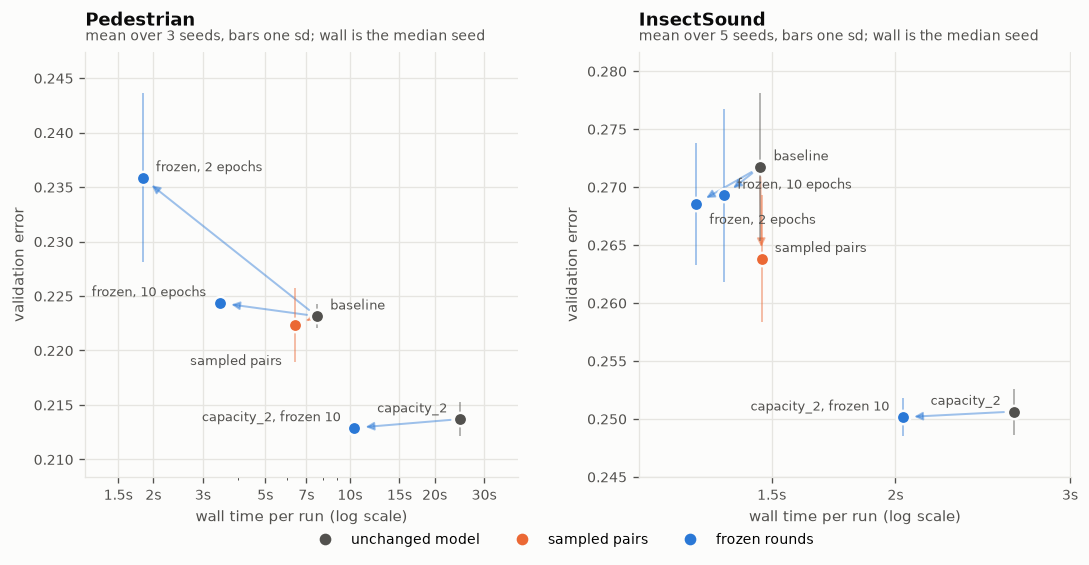

In [6]:
FAMILY = {
    "baseline": UNCHANGED,
    "capacity_2": UNCHANGED,
    "sampled_pairs": SAMPLED,
    "frozen_2ep": FROZEN,
    "frozen_10ep": FROZEN,
    "frozen_10ep_capacity_2": FROZEN,
}

# each change drawn as a move from the model it changes
MOVES = [
    ("baseline", "sampled_pairs", SAMPLED),
    ("baseline", "frozen_10ep", FROZEN),
    ("baseline", "frozen_2ep", FROZEN),
    ("capacity_2", "frozen_10ep_capacity_2", FROZEN),
]

NAMES = {
    "baseline": "baseline",
    "capacity_2": "capacity_2",
    "sampled_pairs": "sampled pairs",
    "frozen_2ep": "frozen, 2 epochs",
    "frozen_10ep": "frozen, 10 epochs",
    "frozen_10ep_capacity_2": "capacity_2, frozen 10",
}

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.6), gridspec_kw={"wspace": 0.28})

for ax, dataset in zip(axes, SWEEPS):
    table = variants[variants["dataset"] == dataset].set_index("variant")

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 1.5, 2.0, 3.0, 5.0, 7.0)))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}s"))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.margins(x=0.18, y=0.12)

    for start, end, colour in MOVES:
        if start in table.index and end in table.index:
            a, b = table.loc[start], table.loc[end]
            ax.annotate(
                "",
                xy=(b["wall_s"], b["error"]),
                xytext=(a["wall_s"], a["error"]),
                arrowprops={
                    "arrowstyle": "-|>",
                    "color": colour,
                    "alpha": 0.45,
                    "lw": 1.2,
                    "shrinkA": 6,
                    "shrinkB": 7,
                },
                zorder=2,
            )

    for name, row in table.iterrows():
        colour = FAMILY.get(name, MUTED)
        ax.errorbar(
            row["wall_s"],
            row["error"],
            yerr=row["sd"],
            fmt="none",
            ecolor=colour,
            elinewidth=1.0,
            alpha=0.5,
            zorder=3,
        )
        dot(ax, row["wall_s"], row["error"], colour)

    seeds_here = int(table["seeds"].iloc[0])
    finish(
        ax,
        title=dataset,
        note=f"mean over {seeds_here} seeds, bars one sd; wall is the median seed",
        xlabel="wall time per run (log scale)",
        ylabel="validation error",
    )

    place_labels(
        ax,
        [
            (row["wall_s"], row["error"], NAMES.get(name, name))
            for name, row in table.iterrows()
        ],
    )

legend_below(
    fig,
    [
        Line2D([], [], color=UNCHANGED, marker="o", ls="none", label="unchanged model"),
        Line2D([], [], color=SAMPLED, marker="o", ls="none", label="sampled pairs"),
        Line2D([], [], color=FROZEN, marker="o", ls="none", label="frozen rounds"),
    ],
)

plt.show()

## 2. What freezing does to a streamed run's accuracy

Validation error as rounds accumulate, one line per window, drawn as a rolling
mean over seven evaluations with the raw evaluations faint behind it: on 4,096
validation rows, consecutive evaluations of the same run differ by as much as
0.01, so a single final value is not worth comparing. The grey rules are
where each window starts to freeze. Each line is a single run.

**A 2-epoch window costs nothing measurable on either dataset**: over the last
seven evaluations it averages 0.3877 against 0.3922 unfrozen on Traffic, and
0.0751 against 0.0745 on LenDB. A 1-epoch window splits: 0.0698 on LenDB,
but 0.4052 on Traffic, 0.013 behind -- the one gap here larger than the
noise, and a single run, so a lead rather than a result.

Traffic also shows what streaming the whole pool buys. The same validation
rows scored 0.4404 for HashBoost trained on 65,536 of them, and 0.3997 and
0.3950 for XGBoost and LightGBM on that slice; ten epochs over all 1,160,582
rows land level with the tree models. LenDB, as the README's streaming section
found, is capacity-bound over five epochs and does not show the same jump.

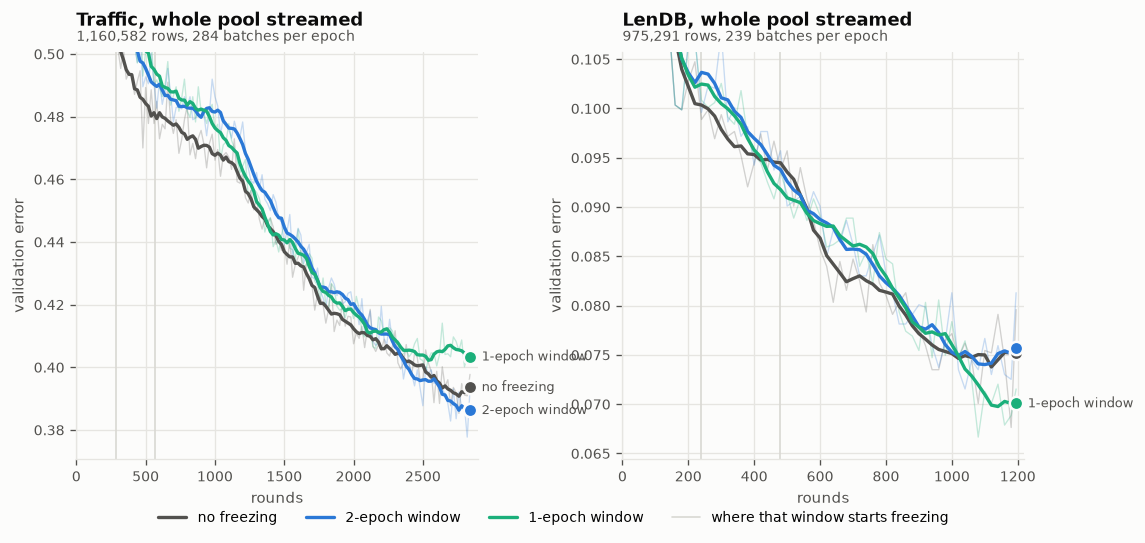

In [7]:
# the gap between panels and the right margin are where the line-end labels go
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), gridspec_kw={"wspace": 0.36})
fig.subplots_adjust(right=0.87)

for ax, dataset in zip(axes, STREAMS):
    here = runs[runs["dataset"] == dataset]
    tops, ends = [], []

    for label, name in RUN_LABELS.items():
        run = here[here["run"] == label]
        if run.empty:
            continue

        curve = points[(points["dataset"] == dataset) & (points["run"] == label)]
        colour = RUN_COLOURS[label]

        ax.plot(curve["round"], curve["va"], color=colour, lw=0.8, alpha=0.25, zorder=2)
        ax.plot(curve["round"], curve["va_smooth"], color=colour, zorder=3)
        dot(ax, curve["round"].iloc[-1], curve["va_smooth"].iloc[-1], colour)

        tops.append(curve["va_smooth"].iloc[len(curve) // 5 :].max())
        ends.append((curve["round"].iloc[-1], curve["va_smooth"].iloc[-1], name))

        start = run["freezes_from"].iloc[0]
        if start:
            ax.axvline(start, color=PALE, lw=1.0, zorder=1)

    # the opening rounds sit far above where the curves settle, so the scale
    # starts a fifth of the way in; the table has every point
    bottom = points[points["dataset"] == dataset]["va"].min()
    pad = 0.06 * (max(tops) - bottom)
    ax.set_ylim(bottom - pad, max(tops) + pad)

    ax.set_xlim(0, points[points["dataset"] == dataset]["round"].max() * 1.02)

    finish(
        ax,
        title=f"{dataset}, whole pool streamed",
        note=f"{int(here['rows'].iloc[0]):,} rows, "
        f"{int(here['per_epoch'].iloc[0])} batches per epoch",
        xlabel="rounds",
        ylabel="validation error",
    )

    end_labels(ax, ends)

legend_below(
    fig,
    [Line2D([], [], color=RUN_COLOURS[k], label=v) for k, v in RUN_LABELS.items()]
    + [Line2D([], [], color=PALE, lw=1.0, label="where that window starts freezing")],
)

plt.show()

## 3. What a batch costs as the model grows

Time inside `fit_batch` per batch, differenced from the timeline every run
records, again smoothed over seven evaluations. Without freezing it grows
linearly with the model: on Traffic from 2 ms to 14.5 ms over 2,840 rounds,
about 3.5 ms per thousand. With a window it stops growing once each batch is
doing the window plus the rounds frozen since its rows were last seen, and sits
near 7.5 ms for both windows -- the fixed per-batch work, not the rounds, is
most of what remains.

LenDB tells the same story at a smaller scale. Its fixed work is larger, the
14,940-column transpose and encoding put ~7 ms under every batch, and five
epochs are only 1,195 rounds, so the unfrozen line has only climbed to 9.4 ms
when the 1-epoch window flattens at 8.4 ms.

The note on each panel is the steady cost of reading and transforming a batch,
which neither line includes.

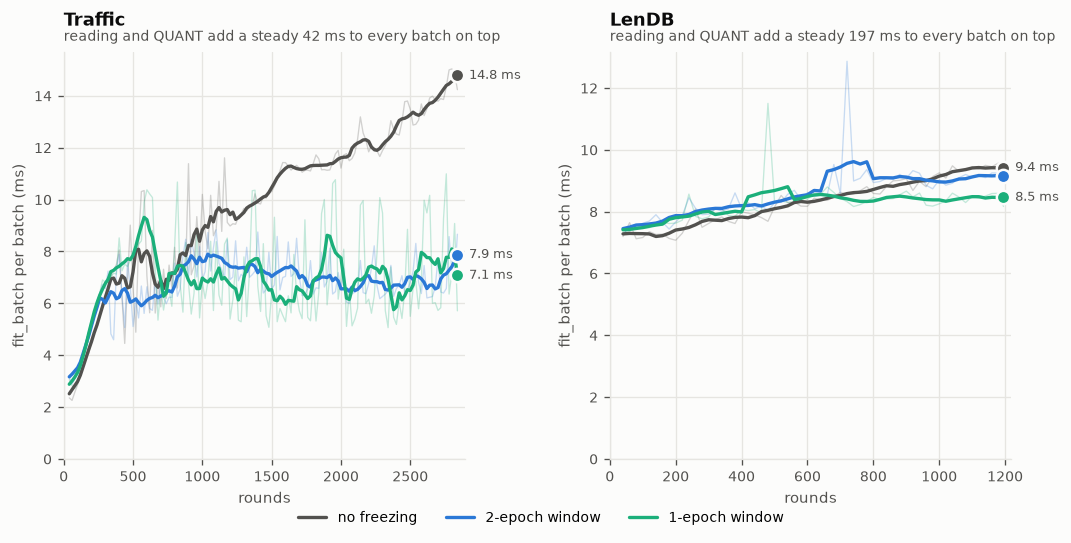

In [8]:
# the gap between panels and the right margin are where the line-end labels go
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4), gridspec_kw={"wspace": 0.36})
fig.subplots_adjust(right=0.87)

for ax, dataset in zip(axes, STREAMS):
    ends = []

    for label in RUN_LABELS:
        curve = points[
            (points["dataset"] == dataset) & (points["run"] == label)
        ].dropna(subset=["fit_ms"])
        if curve.empty:
            continue

        colour = RUN_COLOURS[label]
        last = curve["fit_ms_smooth"].iloc[-1]

        ax.plot(
            curve["round"], curve["fit_ms"], color=colour, lw=0.8, alpha=0.25, zorder=2
        )
        ax.plot(curve["round"], curve["fit_ms_smooth"], color=colour, zorder=3)
        dot(ax, curve["round"].iloc[-1], last, colour)
        ends.append((curve["round"].iloc[-1], last, f"{last:.1f} ms"))

    pipeline = points[points["dataset"] == dataset]["pipeline_ms"].median()

    ax.set_ylim(bottom=0)

    ax.set_xlim(0, points[points["dataset"] == dataset]["round"].max() * 1.02)

    finish(
        ax,
        title=dataset,
        note=f"reading and QUANT add a steady {pipeline:.0f} ms to every batch on top",
        xlabel="rounds",
        ylabel="fit_batch per batch (ms)",
    )

    end_labels(ax, ends)

legend_below(
    fig,
    [Line2D([], [], color=RUN_COLOURS[k], label=v) for k, v in RUN_LABELS.items()],
)

plt.show()

## 4. Where the wall time goes

**In a streamed run the model is the smaller part.** `fit_batch` is 19% of the
unfrozen Traffic run and 14-15% of the frozen ones; on LenDB it is under 4%,
with QUANT at 56% and reading the memmap at 40%.

Freezing cut Traffic's model time by nearly a third, 29 s to 20-21 s. That is
real, and still smaller than QUANT's own run-to-run spread of 114-125 s, which
is why the frozen bars do not line up neatly by window. At these lengths the
next thing worth speeding up in a streamed run is the feature transform.

Freezing is insurance for longer runs. Extrapolating Traffic's measured
slope, the unfrozen model would cost as much per batch as reading and QUANT
together (42 ms) at around 11,000 rounds, roughly 38 epochs -- and would keep
growing after, where a frozen one stays flat.

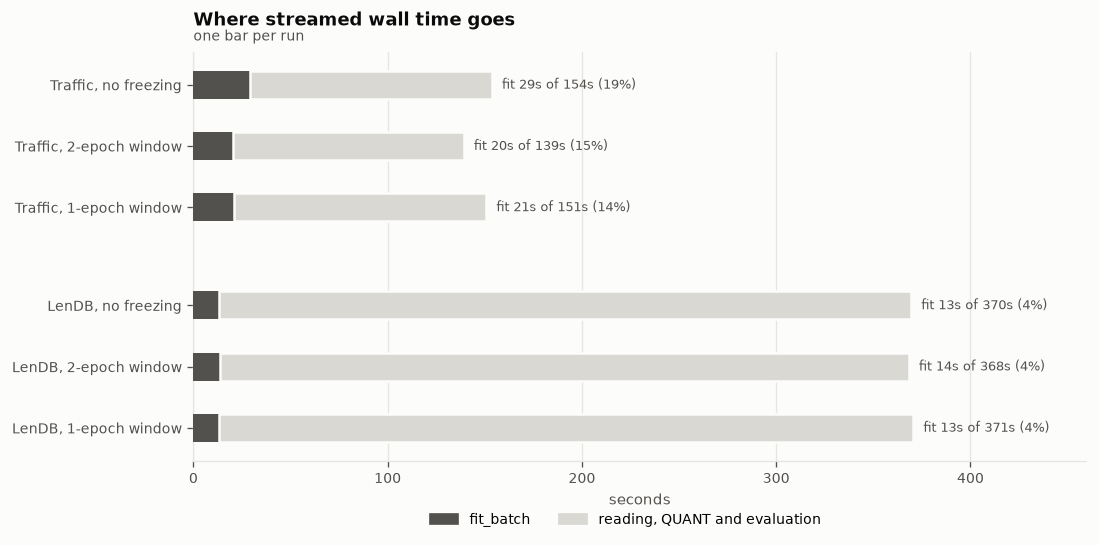

In [9]:
order = [(d, label) for d in STREAMS for label in RUN_LABELS]
bars = runs.set_index(["dataset", "run"]).reindex(order).dropna(subset=["wall_s"])

# a gap between datasets, so the three runs of each read as a group
position, positions, last = 0.0, [], None
for dataset, _ in bars.index:
    if last is not None and dataset != last:
        position += 0.6
    positions.append(position)
    position += 1.0
    last = dataset
y = -np.array(positions)

fig, ax = plt.subplots(figsize=(9.6, 0.42 * len(bars) + 1.9))

for yi, ((dataset, label), row) in zip(y, bars.iterrows()):
    ax.barh(yi, row["fit_s"], height=0.46, color=INK_2, zorder=3)
    ax.barh(
        yi,
        row["wall_s"] - row["fit_s"],
        left=row["fit_s"],
        height=0.46,
        color=PALE,
        edgecolor=SURFACE,
        linewidth=1.5,
        zorder=3,
    )
    ax.annotate(
        f"fit {row['fit_s']:.0f}s of {row['wall_s']:.0f}s ({row['fit_share']:.0%})",
        (row["wall_s"], yi),
        textcoords="offset points",
        xytext=(6, 0),
        va="center",
        fontsize=8,
        color=INK_2,
    )

ax.set_yticks(y)
ax.set_yticklabels([f"{d}, {RUN_LABELS[label]}" for d, label in bars.index])
ax.grid(axis="y", visible=False)
ax.margins(x=0.24)

finish(
    ax,
    title="Where streamed wall time goes",
    note="one bar per run",
    xlabel="seconds",
)

legend_below(
    fig,
    [
        Rectangle((0, 0), 1, 1, color=INK_2, label="fit_batch"),
        Rectangle((0, 0), 1, 1, color=PALE, label="reading, QUANT and evaluation"),
    ],
)

plt.show()